In [1]:
# letterdata.csv
#https://mitu.co.in/datasets

#### import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the data

In [3]:
df = pd.read_csv('D:/NLP_CV/NLP/datasets/letterdata.csv')
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [4]:
x = df.drop('letter' , axis = 1)
y = df['letter']

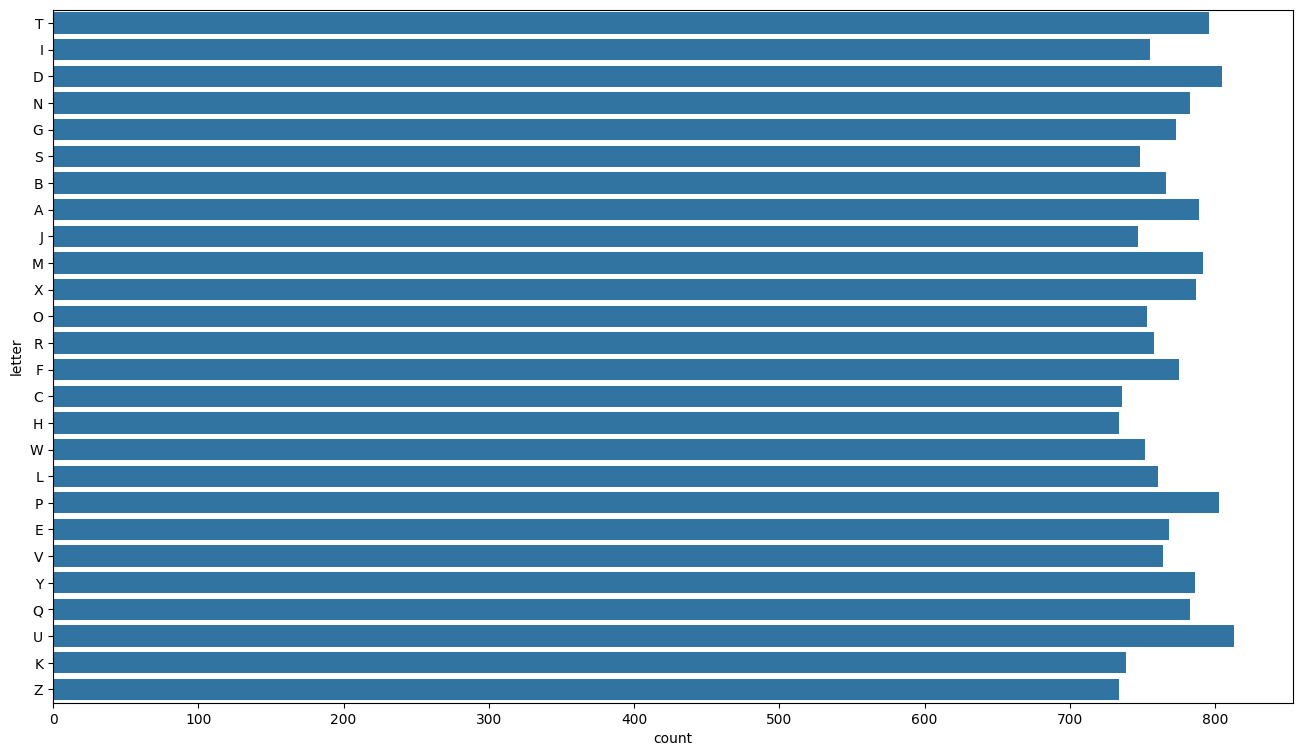

In [5]:
plt.figure(figsize=(16 , 9))
sns.countplot(y = y);

#### Cross Validation

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0, test_size=0.2)

In [7]:
x_train.shape

(16000, 16)

In [8]:
x_test.shape

(4000, 16)

#### Build The Model

In [10]:
from sklearn.ensemble import RandomForestClassifier

In [11]:
rf = RandomForestClassifier(random_state=0, n_estimators=20)

In [12]:
rf.fit(x_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Train accuracy: 0.99975
Test accuracy:  0.953

Classification report:
               precision    recall  f1-score   support

           A       0.97      0.99      0.98       147
           B       0.89      0.95      0.92       158
           C       0.97      0.97      0.97       156
           D       0.90      0.96      0.93       171
           E       0.94      0.92      0.93       145
           F       0.94      0.92      0.93       167
           G       0.92      0.93      0.93       182
           H       0.91      0.85      0.88       123
           I       0.97      0.92      0.94       127
           J       0.97      0.94      0.96       159
           K       0.92      0.92      0.92       143
           L       0.97      0.96      0.97       159
           M       0.97      0.95      0.96       173
           N       0.96      0.96      0.96       134
           O       0.97      0.98      0.98       142
           P       0.96      0.96      0.96       165
          

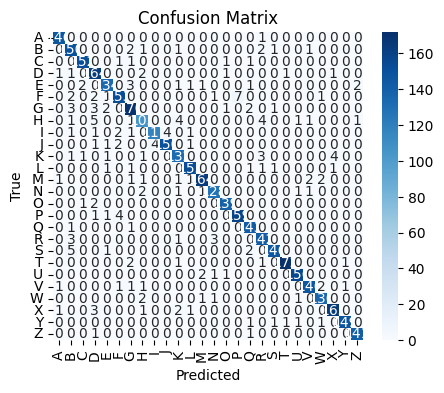

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
y_pred = rf.predict(x_test)
y_train_pred = rf.predict(x_train)

# Metrics
print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

In [16]:
rf.feature_importances_

array([0.02239203, 0.02566732, 0.02311828, 0.02154923, 0.02537044,
       0.05488616, 0.06409146, 0.08168569, 0.09808875, 0.07414187,
       0.07924167, 0.08115063, 0.1222804 , 0.07335313, 0.09756412,
       0.05541881])

In [18]:
new = x_test.iloc[[100],:]

In [20]:
new

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
18044,1,3,2,1,1,7,7,5,5,6,6,9,2,8,3,9


In [19]:
rf.predict(new)

array(['G'], dtype=object)

In [21]:
y_test.iloc[100]

'G'